<a href="https://colab.research.google.com/github/RapoluUma956/Navigation-and-Sensor-data-error-minimization-using-AI/blob/main/LSTM_attitude_Estimation_2/LSTM_Attitude_Estimation_Exp_22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Import Libraries**

In [84]:
from numpy import array
from tensorflow.keras.preprocessing.text import one_hot
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Dense
from tensorflow.keras.layers import Flatten, LSTM, Conv1D, RNN, SimpleRNN
from tensorflow.keras.layers import GlobalMaxPooling1D, Bidirectional
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Embedding
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Concatenate
from tensorflow.keras.layers import Bidirectional
from sklearn import preprocessing
from tensorflow.keras import regularizers
from sklearn.metrics import mean_squared_error
from math import sqrt
import pandas as pd
import numpy as np
import re
from tensorflow.keras.utils import plot_model
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt
import math
from scipy.io import loadmat
import time

## **Import Data**

In [85]:
dataset_paths = {
    "D1": "/content/drive/MyDrive/LSTM-DRDO/D1.xlsx",
    "D2": "/content/drive/MyDrive/LSTM-DRDO/D2.xlsx",
    "D3": "/content/drive/MyDrive/LSTM-DRDO/D3.xlsx",
    "D4": "/content/drive/MyDrive/LSTM-DRDO/D4.xlsx",
    "D5": "/content/drive/MyDrive/LSTM-DRDO/D5.xlsx",
    "D6": "/content/drive/MyDrive/LSTM-DRDO/D6.xlsx",
}

test_dataset_name = "D6"   # change this later to D1, D2, D3, etc.

train_dfs = []
test_df = None

for name, path in dataset_paths.items():
    df = pd.read_excel(path)
    print(name, df.shape)

    if name == test_dataset_name:
        test_df = df
    else:
        train_dfs.append(df)

train_df = pd.concat(train_dfs, ignore_index=True)

train_data = np.array(train_df)
test_data = np.array(test_df)

print("Training data shape:", train_data.shape)
print("Testing data shape:", test_data.shape)

D1 (17219, 12)
D2 (11399, 12)
D3 (11429, 12)
D4 (14400, 12)
D5 (22252, 12)
D6 (34862, 12)
Training data shape: (76699, 12)
Testing data shape: (34862, 12)


In [86]:
trainX = train_data[:, 0:9]
trainY = train_data[:, 9:12]

testX = test_data[:, 0:9]
testY = test_data[:, 9:12]

In [87]:
# Scale training and testing datasets
x_scaler = MinMaxScaler()

trainX = x_scaler.fit_transform(trainX)
testX = x_scaler.transform(testX)

input_dim = trainX.shape[1]

timestep = 2

# Make training length divisible by timestep
train_len = (len(trainX) // timestep) * timestep

trainX = trainX[:train_len]
trainY = trainY[:train_len]

# Make testing length divisible by timestep
test_len = (len(testX) // timestep) * timestep

testX = testX[:test_len]
testY = testY[:test_len]

print("Input Dimension :", input_dim)
print("Training Samples :", train_len)
print("Testing Samples  :", test_len)

Input Dimension : 9
Training Samples : 76698
Testing Samples  : 34862


## **Split Training and Testing Data**

In [88]:
Xphithetapsi = trainX.reshape(
    train_len // timestep,
    timestep,
    input_dim
)

Yphithetapsi = np.array(trainY[0::timestep])

# Test data (used later)
dataXv = testX
dataYv = testY

print("Xphithetapsi shape :", Xphithetapsi.shape)
print("Yphithetapsi shape :", Yphithetapsi.shape)

Xphithetapsi shape : (38349, 2, 9)
Yphithetapsi shape : (38349, 3)


## **Model desing and Training**

In [89]:
inputs = Input(name='inputs',shape=[timestep,input_dim])
layer = LSTM(50, return_sequences=True)(inputs)
layer = Dropout(0.25)(layer)
layer = LSTM(20)(layer)
outputs = Dense(3, activation='linear')(layer)

modelphithetapsi1 = Model(inputs=[inputs],outputs=[outputs])

# Compile
modelphithetapsi1.compile(optimizer='Adam', loss='mean_squared_error',metrics = ['accuracy'])
modelphithetapsi1.summary()

history = modelphithetapsi1.fit(Xphithetapsi, Yphithetapsi,
                       epochs=20,
                       verbose=0,
                       batch_size=50)

print('Model Training done')

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inputs (InputLayer)             │ (None, 2, 9)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 2, 50)          │        12,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 2, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 20)             │         5,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            63 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,743 (69.31 KB)

 Trainable params: 17,743 (69.31 KB)

 Non-trainable params: 0 (0.00 B)

Model Training done


## **Offline Predictions**

In [90]:
results = []

Xtestt = dataXv
Ytestt = dataYv

usable_len = (len(Xtestt) // timestep) * timestep

Xtestt = Xtestt[:usable_len]
Ytestt = Ytestt[:usable_len]

Ytest = np.array(Ytestt[0::timestep])
Xtest = np.array(Xtestt[:, 0:9])

ip = Xtest.reshape(usable_len // timestep, timestep, input_dim)

test_output = modelphithetapsi1.predict(ip)

results = np.array(test_output)
print("results shape:", results.shape)
print("Ytest shape:", Ytest.shape)

545/545 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
results shape: (17431, 3)
Ytest shape: (17431, 3)


## **Incremental Learning Model**

In [91]:
# new model for incremental learning
model = Model(inputs=[inputs],outputs=[outputs])
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae', 'mse']
)
model.summary()
#copy weights
Wsave = modelphithetapsi1.get_weights()
model.set_weights(Wsave)

wgt = model.get_weights()
print(wgt[1])

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inputs (InputLayer)             │ (None, 2, 9)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 2, 50)          │        12,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 2, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 20)             │         5,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            63 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,743 (69.31 KB)

 Trainable params: 17,743 (69.31 KB)

 Non-trainable params: 0 (0.00 B)

[[-1.2880783  -0.55055946  0.03083902 ...  0.22570871 -1.4322989
  -0.38981012]
 [-1.2284174  -1.4887223  -1.0862709  ...  0.43488684 -1.5284227
  -0.46252152]
 [ 0.67504954  0.6603514   0.4672089  ...  0.6123224   0.4763723
   0.5896956 ]
 ...
 [ 0.6998927   0.8579946   0.48298067 ...  0.948724    0.43057105
   0.7864528 ]
 [ 0.970854    0.6552339   0.6180146  ...  0.39733326  1.1375842
   0.09248555]
 [-0.9942281  -0.77756494 -0.6011498  ... -0.3045585  -0.63084286
  -0.20611477]]


In [92]:
result = []

stepinit = 3000
timestep = 2

total_test_rows = dataXv.shape[0]
num_chunks = total_test_rows // stepinit
araya = [stepinit] * num_chunks

print("Total test rows:", total_test_rows)
print("Full chunks:", num_chunks)

for j in range(num_chunks):
    pt = stepinit * j

    Xtestt = dataXv[pt:pt + stepinit]
    Ytestt = dataYv[pt:pt + stepinit]

    usable_len = (len(Xtestt) // timestep) * timestep

    Xtestt = Xtestt[:usable_len]
    Ytestt = Ytestt[:usable_len]

    Xtest = np.array(Xtestt[:, 0:9])
    Ytest = np.array(Ytestt[0::timestep])

    ip = Xtest.reshape(usable_len // timestep, timestep, input_dim)

    test_output = model.predict(ip)
    result.append(test_output)

    start = time.time()
    history = model.fit(
        ip,
        Ytest,
        epochs=20,
        verbose=0,
        batch_size=50
    )
    end = time.time()

    print("Training time:", end - start)

if len(result) > 0:
    result = np.vstack(result)
else:
    result = np.empty((0, 3))

print("result shape:", result.shape)


# remaining data block
result1 = []

pt = stepinit * num_chunks
step = total_test_rows - pt

print("Remaining step:", step)

if step > 0:
    Xtestt = dataXv[pt:pt + step]
    Ytestt = dataYv[pt:pt + step]

    usable_len = (len(Xtestt) // timestep) * timestep

    if usable_len > 0:
        Xtestt = Xtestt[:usable_len]
        Ytestt = Ytestt[:usable_len]

        Xtest = np.array(Xtestt[:, 0:9])
        Ytest = np.array(Ytestt[0::timestep])

        ip = Xtest.reshape(usable_len // timestep, timestep, input_dim)

        test_output = model.predict(ip)
        result1.append(test_output)

        result1 = np.vstack(result1)
    else:
        result1 = np.empty((0, 3))
else:
    result1 = np.empty((0, 3))

print("result1 shape:", result1.shape)


# combine both
if result1.shape[0] > 0:
    results = np.vstack((result, result1))
else:
    results = result

print("Final results shape:", results.shape)

Total test rows: 34862
Full chunks: 11
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Training time: 6.897330284118652
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Training time: 4.298953056335449
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Training time: 5.989567518234253
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Training time: 4.182970285415649
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Training time: 4.560279846191406
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Training time: 5.262999534606934
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Training time: 4.282547473907471
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Training time: 6.025914192199707
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Training time: 4.1714277267456055
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Training time: 4.221776008605957
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Training time: 5.703100681304932
result shape: (16500, 3)
Remaining step: 1862
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
result1 shape: (931, 3)
Final results shape: (17431, 3)


## **Compute RMSE and Print Results**

Yt shape: (17431, 3)
test_output shape: (17431, 3)
Final Yt shape: (17431, 3)
Final test_output shape: (17431, 3)
RMSE phi/roll: 1.6412585033173357
RMSE theta/pitch: 0.363205593622185
RMSE psi/yaw: 0.9211044579901844
MAE phi/roll: 0.8308469684475824
MAE theta/pitch: 0.23396347477269883
MAE psi/yaw: 0.5069324859113009
R2 phi/roll: 0.3611278891405474
R2 theta/pitch: 0.8617221810966668
R2 psi/yaw: 0.5371798042454197


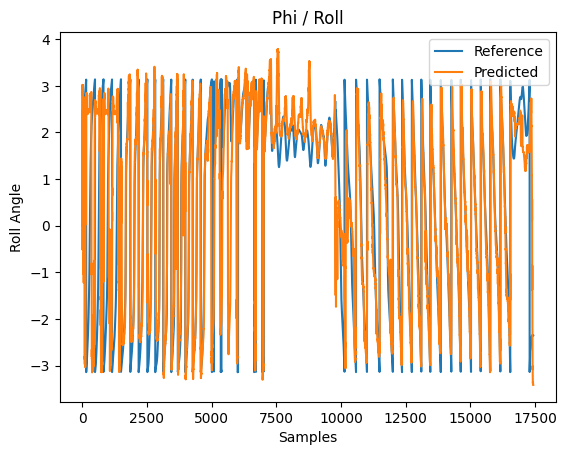

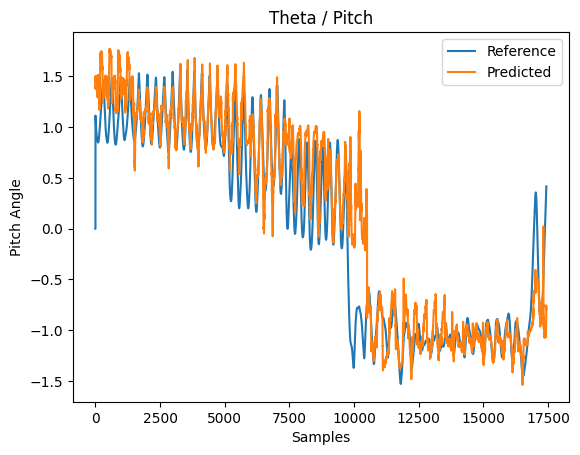

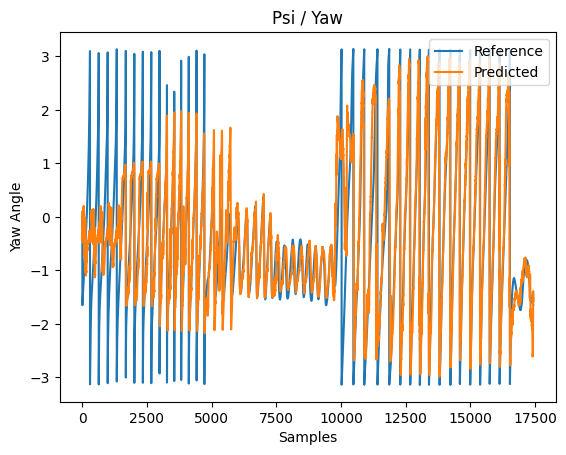

In [93]:
Yt = np.array(dataYv[0::timestep])
test_output = np.array(results)

print("Yt shape:", Yt.shape)
print("test_output shape:", test_output.shape)

# match lengths
min_len = min(Yt.shape[0], test_output.shape[0])

Yt = Yt[:min_len]
test_output = test_output[:min_len]

print("Final Yt shape:", Yt.shape)
print("Final test_output shape:", test_output.shape)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt

rmsephi = sqrt(mean_squared_error(Yt[:, 0], test_output[:, 0]))
rmsetheta = sqrt(mean_squared_error(Yt[:, 1], test_output[:, 1]))
rmsepsi = sqrt(mean_squared_error(Yt[:, 2], test_output[:, 2]))

maephi = mean_absolute_error(Yt[:, 0], test_output[:, 0])
maetheta = mean_absolute_error(Yt[:, 1], test_output[:, 1])
maepsi = mean_absolute_error(Yt[:, 2], test_output[:, 2])

r2phi = r2_score(Yt[:, 0], test_output[:, 0])
r2theta = r2_score(Yt[:, 1], test_output[:, 1])
r2psi = r2_score(Yt[:, 2], test_output[:, 2])

print("RMSE phi/roll:", rmsephi)
print("RMSE theta/pitch:", rmsetheta)
print("RMSE psi/yaw:", rmsepsi)

print("MAE phi/roll:", maephi)
print("MAE theta/pitch:", maetheta)
print("MAE psi/yaw:", maepsi)

print("R2 phi/roll:", r2phi)
print("R2 theta/pitch:", r2theta)
print("R2 psi/yaw:", r2psi)

plt.plot(Yt[:, 0])
plt.plot(test_output[:, 0])
plt.title('Phi / Roll')
plt.xlabel('Samples')
plt.ylabel('Roll Angle')
plt.legend(['Reference', 'Predicted'], loc='upper right')
plt.show()

plt.plot(Yt[:, 1])
plt.plot(test_output[:, 1])
plt.title('Theta / Pitch')
plt.xlabel('Samples')
plt.ylabel('Pitch Angle')
plt.legend(['Reference', 'Predicted'], loc='upper right')
plt.show()

plt.plot(Yt[:, 2])
plt.plot(test_output[:, 2])
plt.title('Psi / Yaw')
plt.xlabel('Samples')
plt.ylabel('Yaw Angle')
plt.legend(['Reference', 'Predicted'], loc='upper right')
plt.show()